### Trabalho 1: Replicação de "A Bibliometric Analysis of Edge Computing for Internet of Things"

***

#### 0: Setup inicial do dataframe

In [1]:
import pandas as pd
import glob # Biblioteca para encontrar arquivos

# --- O SCRIPT FAZ A MÁGICA A PARTIR DAQUI ---

# 1. Encontra todos os arquivos .txt na pasta
# Mude o padrão se seus arquivos tiverem nomes diferentes, ex: 'exportacao_*.txt'
caminho_dos_arquivos = glob.glob('*.txt')
print(f"Arquivos encontrados: {caminho_dos_arquivos}")

# Lista para guardar os DataFrames de cada arquivo
lista_de_dfs = []

# 2. Lê cada arquivo e adiciona a uma lista
for arquivo in caminho_dos_arquivos:
    try:
        # Lê o arquivo original (exportado como "Tab Delimited File")
        df_temp = pd.read_csv(arquivo, sep='\t', encoding='utf-8', on_bad_lines='warn', dtype=str)
        lista_de_dfs.append(df_temp)
        print(f"Arquivo '{arquivo}' lido com sucesso.")
    except Exception as e:
        print(f"Erro ao ler o arquivo {arquivo}: {e}")

# 3. Combina todos os DataFrames da lista em um só
if lista_de_dfs:
    df = pd.concat(lista_de_dfs, ignore_index=True)
    print(f"\nTodos os arquivos foram combinados. Total de registros: {len(df)}")

    # O resto do seu código para renomear e salvar o CSV continua aqui...
    mapa_de_colunas = {
        'AU': 'Authors', 'AF': 'Author Full Names', 'TI': 'Article Title',
        'SO': 'Source Title', 'DE': 'Author Keywords', 'ID': 'Keywords Plus',
        'C1': 'Addresses', 'C3': 'Affiliations', 'RP': 'Reprint Addresses',
        'NR': 'Cited Reference Count', 'TC': 'Times Cited, WoS Core',
        'Z9': 'Times Cited, All Databases', 'PU': 'Publisher',
        'JI': 'Journal Abbreviation', 'J9': 'Journal ISO Abbreviation',
        'PY': 'Publication Year'
    }

    colunas_para_manter = list(mapa_de_colunas.keys())
    colunas_existentes = [col for col in colunas_para_manter if col in df.columns]
    
    df_filtrado = df[colunas_existentes]
    df_renomeado = df_filtrado.rename(columns=mapa_de_colunas)
    
    arquivo_de_destino = 'base_final_formatada.csv'
    df_renomeado.to_csv(arquivo_de_destino, index=False, encoding='utf-8-sig')
    
    print(f"\nSUCESSO! ✨ Seu novo arquivo '{arquivo_de_destino}' foi criado.")
else:
    print("\nNenhum arquivo de dados foi lido. Verifique se os arquivos .txt estão na pasta correta.")

Arquivos encontrados: ['savedrecs (2).txt', 'savedrecs (4).txt']
Arquivo 'savedrecs (2).txt' lido com sucesso.
Arquivo 'savedrecs (4).txt' lido com sucesso.

Todos os arquivos foram combinados. Total de registros: 1896

SUCESSO! ✨ Seu novo arquivo 'base_final_formatada.csv' foi criado.


In [2]:
from geopy.geocoders import Nominatim
import numpy as np
import pandas as pd
from tqdm import tqdm
import math
import time
import matplotlib.pyplot as plt

df = pd.read_csv('base_final_formatada.csv')

***

#### 1: Analysis of Core Literature Studies

> *3.1. Analysis of Core Literature Studies.* The main literature studies on  were highlighted. The top 10 most cited literatures in the world are listed in Table 1. These literature studies have had the widest influence in .

- Nesta seção, eles mostram quais papers são os mais citados e influentes
- Aqui, esperamos ter resultados bem similares (senão iguais) aos deles, dado que os papers seminais do campo não vão ter mudado de 2020 pra hoje
- Acredito que esse resultado é apenas uma lista de 10 artigos ordenadas pelo maior **número total** de citações, com o número médio de citações calculado a partir do ano de publicação do paper.
	- por ex.: eles usam o número de citações feitas apenas por outros artigos na base, ou buscam esse # total em outras fontes também?

Formato do resultado final: (10 linhas no total, 3 mostradas aqui por brevidade)

| Number | Literature title                                                 | Total citation | Average citation per year |
| ------ | ---------------------------------------------------------------- | -------------- | ------------------------- |
| 1      | Edge Computing: Vision and Challenges                            | 1342           | 268.4                     |
| 2      | A Survey on Mobile Edge Computing: The Communication Perspective | 836            | 209                       |
| 3      | Fog and IoT: An Overview of Research Opportunities               | 801            | 160.2                     |

**Não esquecer de somar 1 à quantidade de anos para o denominador do número médio de citações. Os autores fazem isso porque a pesquisa foi feita no final do ano de 2020.**

In [3]:
df = df.sort_values(by="Times Cited, All Databases", ascending=False)

CURRENT_YEAR = 2025

mostCited10 = df.loc[0:9, ["Article Title", "Times Cited, All Databases", "Publication Year"]] #Os autores originais não especificam qual coluna utilizaram, assumindo "All databases" 
mostCited10["Years since Publication"] = CURRENT_YEAR - mostCited10["Publication Year"] + 1 #Soma 1 para considerar 2025 como um ano completo para a média de citações por ano
mostCited10["Average citations per year"] = mostCited10["Times Cited, All Databases"] / mostCited10["Years since Publication"]

mostCited10[["Article Title", "Times Cited, All Databases", "Average citations per year"]].to_csv("output_analise1.csv")

***

#### 2: Analysis of Core Journals

> *3.2. Analysis of Core Journals.* In the development of , journals play an important role as the main disseminators of the process of studies. The top 7 leading journals with the most published literatures in the  field are listed in Table 2.
> 
> ...
> 
> Among them, IEEE Access has published 279 literature studies in this field, ranking first. Meanwhile, the total number of literature studies published by the journals listed in Table 2 reaches 832, accounting for about 30% of all literature studies retrieved
> 
> ...
> 
>  Next, the journal citation totals [33, 34] were studied, that is, the most cited journal and the journal frequently cited by the same source. The minimum number of citations of journals was set 50 in VOSviewer. A visualization of journal cocitation network is shown in Figure 1. In Figure 1, the sizes of dots and words represent the cited times. The larger the dots and words are, the more times they are cited. It can be seen from Figure 1 that IEEE Access and IEEE Internet of Things are cited the most times
> 
>  ...

- Apresentam os top 7 *journals* em número de artigos publicados
	- Por quê 7 não é explicado no artigo, mas vamos manter o mesmo número para a replicação
- Dizem que **30%** das publicações são feitas pelos top 7. Se não houve grande mudança na estrutura destes journals ou mudança de preferências por autores, devemos encontrar aproximadamente o mesmo número, mas não é garantido
- Não explicam a metodologia exata para o "impact Factor", mas olhando online parece ser uma fórmula padrão. provavelmente conseguimos puxar o impact factor de cada um dos top 7 jpurnals que acharmos da internet mesmo, daí adicionamos nas fontes
	- Como nossa base está consolidada com todas as citações desde 2000, não temos calcular o impact factor nós mesmos, só se formos baixar novas bases do WoS.

**Tabela 1:**

<img src="Images/Pasted image 20250816182957.png">


--- Análise 2: Top 7 Periódicos (Core Journals) ---

                                 Periódico (Journal)  Número de Artigos  \
1                   WIRELESS PERSONAL COMMUNICATIONS                 69   
2                                        IEEE ACCESS                 37   
3     INTERNATIONAL JOURNAL OF COMMUNICATION SYSTEMS                 28   
4              IEEE TRANSACTIONS ON MOBILE COMPUTING                 27   
5                                  WIRELESS NETWORKS                 27   
6                                    AD HOC NETWORKS                 27   
7  INTERNATIONAL JOURNAL OF COMPUTER SCIENCE AND ...                 23   

  Fator de Impacto (JCR 2023)  
1                         2.2  
2                         3.6  
3                         1.8  
4                         9.2  
5                         2.1  
6                         4.4  
7                         NaN  
Imagem da tabela salva como 'tabela_analise2.png'


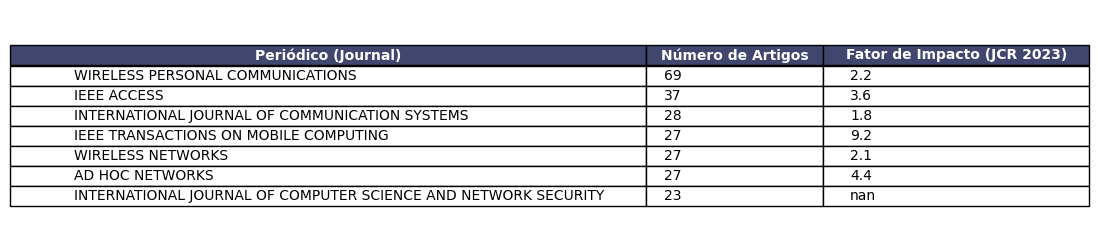

In [4]:
# Passo 1: Contar o número de publicações por periódico.
journal_counts = df['Source Title'].value_counts()

# Passo 2: Selecionar os 7 periódicos com mais publicações.
top_7_journals = journal_counts.head(7)

# Passo 3: Criar um DataFrame formatado com os resultados.
top_7_df = top_7_journals.reset_index()
top_7_df.columns = ['Periódico (Journal)', 'Número de Artigos']
top_7_df.index = np.arange(1, len(top_7_df) + 1)

# Passo 4: Adicionar a coluna de Fator de Impacto (JCR 2023).
# fonte Web of Science™ (WoS) Journal Info Impact Factor
impact_factors = {
    'WIRELESS PERSONAL COMMUNICATIONS': '2.2',
    'IEEE ACCESS': '3.6',
    'INTERNATIONAL JOURNAL OF COMMUNICATION SYSTEMS': '1.8',
    'IEEE TRANSACTIONS ON MOBILE COMPUTING': '9.2',
    'WIRELESS NETWORKS': '2.1',
    'AD HOC NETWORKS': '4.4',
    'INTERNATIONAL JOURNAL OF COMPUTER SCIENCE AND APPLICATIONS': 'N/A'
}
top_7_df['Fator de Impacto (JCR 2023)'] = top_7_df['Periódico (Journal)'].map(impact_factors)

# Passo 5: Gerar e salvar a imagem da tabela.
fig, ax = plt.subplots(figsize=(12, 3)) # Ajuste o tamanho conforme necessário
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=top_7_df.values,
                 colLabels=top_7_df.columns,
                 loc='center',
                 cellLoc='left')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Ajustar largura das colunas (primeira maior, outras menores)
col_widths = [0.6, 0.2, 0.2]  # proporção de largura de cada coluna
for i, width in enumerate(col_widths):
    table.auto_set_column_width([i])  # ajusta automaticamente primeiro
    for key, cell in table.get_celld().items():
        if key[1] == i:  # coluna i
            cell.set_width(width)

# Estilo do cabeçalho
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold', color='w')
        cell.set_facecolor('#40466e')

# Salvar a figura
print("\n--- Análise 2: Top 7 Periódicos (Core Journals) ---\n")
print(top_7_df)
plt.savefig('tabela_analise2.png', bbox_inches='tight', dpi=300)
print("Imagem da tabela salva como 'tabela_analise2.png'")

***

#### 3: Analysis of Core Authors

> *3.3. Analysis of Core Authors.* The core authors are the most productive authors. They are researchers who have published many literature studies in a certain research field. Studying the core authors is conducive to analyzing and finding authoritative  experts. Price’s law in bibliometrics can be used to determine the core author in a research field. Place’s law pointed out the core authors, which can be expressed as follows: 
> 
> `M = 0.749*sqrt(Nmax)`
> 
> where Nmax is the maximum number of literature studies published by the same author and M is the minimum number of literature studies published by the core authors. The authors who published more than M literature studies are the coauthors. As shown in Table 3, the maximum number of literature studies published by the same author in the  field is 27. Then, M = 4. Therefore, the authors who have published more than 4 literature stuides are the coauthors in this field, totaling 466.
> ...
> However, scientometrics have done a great deal of work on how to meaningfully quantify the publication of academic results. They believe that counting the number of literatures is one way, and that counting the total number of citations is considered the other way that is more meaningful
> ...
> The minimum number of citations of the authors was set 50 in VOSviewer. Then, of the 36638 authors, 155 meet this threshold. A density visualization of author cocitation network is shown in Figure 2. If the color is lighter and the words are larger, the author’s number of citations is higher.

- Alguns pontos importantes de tradução a se considerar:
	- Quando os autores dizem "*literature studies*", eles querem dizer qualquer artigo, não apenas revisões de literatura. Eles usam o termo "*literature*" para qualquer manuscrito - papers, artigos, livros etc.
	- "*Coauthors*" nesse parágrafo quer dizer "*Core authors*", não co-autor.
- Para a replicação, temos que:
	- aplicar a lei de Place e achar o total de autores que passam pelo critério (466 no artigo original)
	- Replicar a tabela de 10 autores com o maior número de artigos escritos
	- Encontrar os autores mais citados (critério alternativo deles de relevância de autores)
	- Replicar a figura 2,  com a análise de rede de co-citação de autores (novamente, configuração de `Minimum number of citations of authors = 50` no VOSViewer)

**Tabela 3:**

<img src="Images/Pasted image 20250816185316.png">

         Authors_split  count
0            Tseng, YC     12
1          Datta, Raja     11
2       Bouvry, Pascal     10
3             Cano, JC      9
4           Manzoni, P      9
...                ...    ...
4632            Wu, YN      1
4633          Chou, PA      1
4634          Kung, SY      1
4635   Musolesi, Mirco      1
4636  Mascolo, Cecilia      1

[4637 rows x 2 columns]
12
                  Name  Articles  PlaceLaw
0            Tseng, YC        12      True
1          Datta, Raja        11      True
2       Bouvry, Pascal        10      True
3             Cano, JC         9      True
4           Manzoni, P         9      True
...                ...       ...       ...
4632            Wu, YN         1     False
4633          Chou, PA         1     False
4634          Kung, SY         1     False
4635   Musolesi, Mirco         1     False
4636  Mascolo, Cecilia         1     False

[4637 rows x 3 columns]
226
0.048738408453741645
4637


C:\Users\macap\AppData\Local\Temp\ipykernel_20428\899125202.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


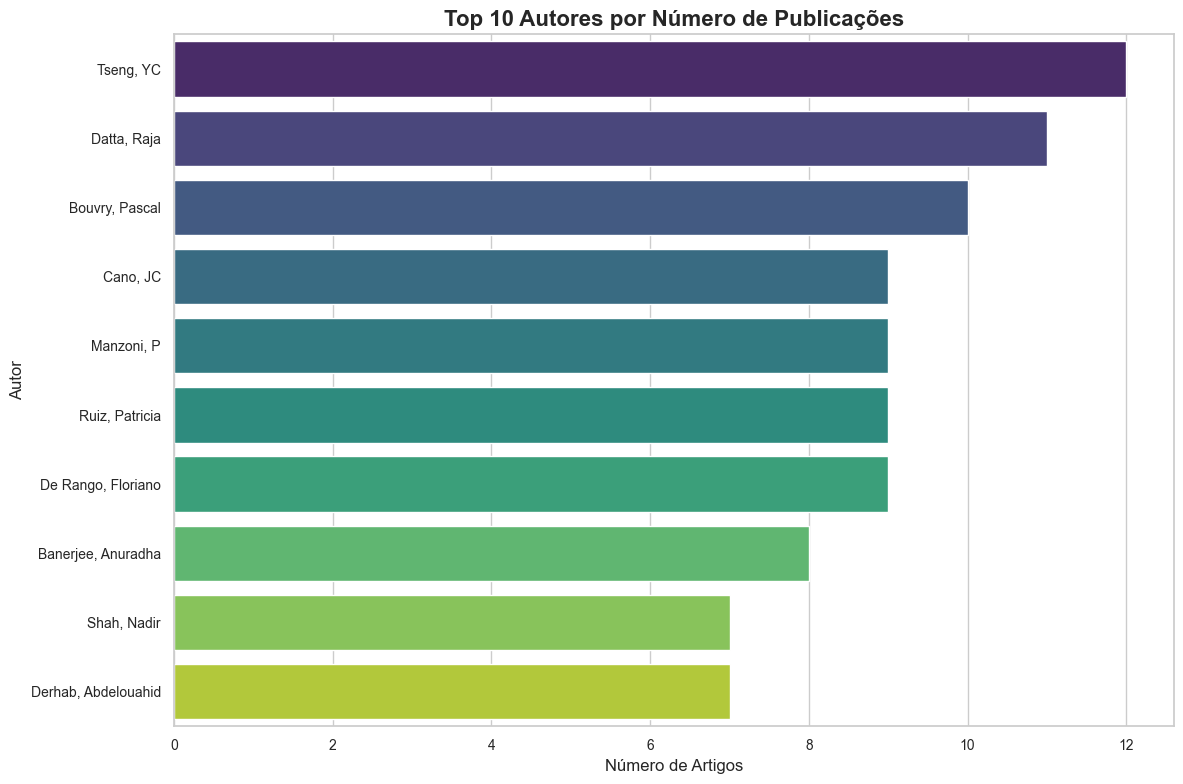

C:\Users\macap\AppData\Local\Temp\ipykernel_20428\899125202.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot_citations = sns.barplot(


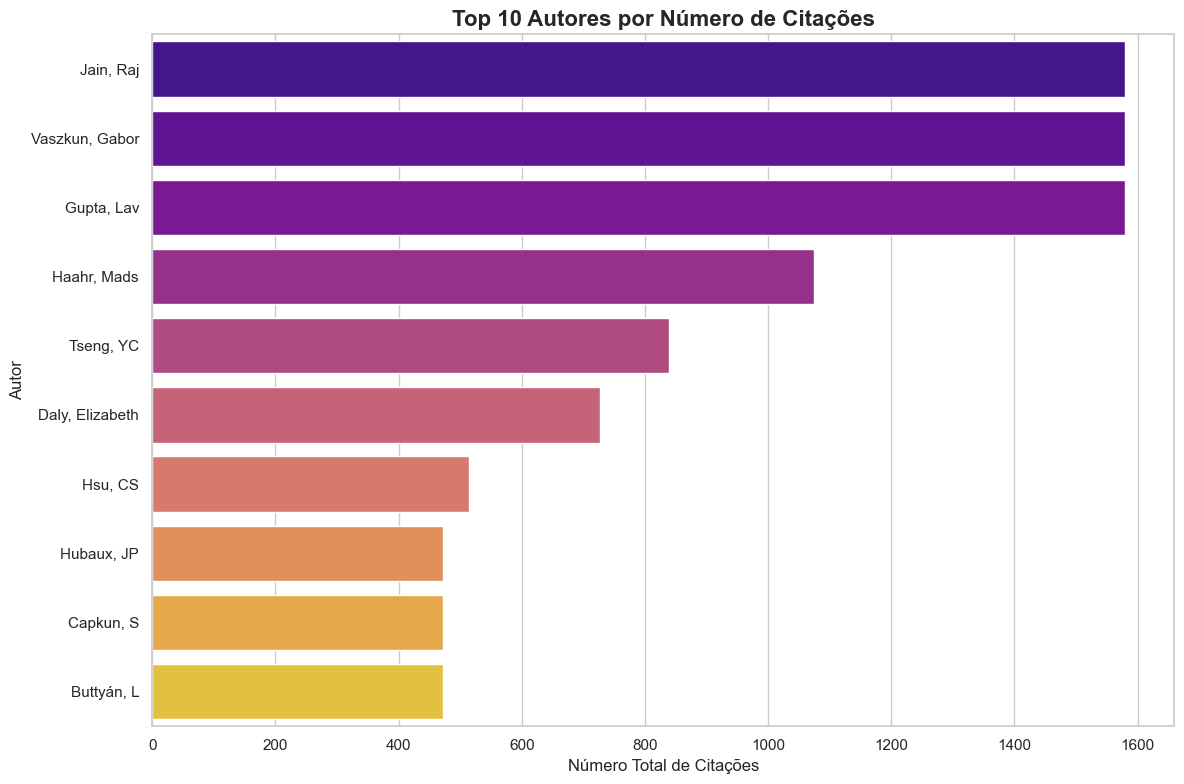


Gráfico 'top_10_autores_citacoes.png' salvo.
          Autor  Total de Citações
      Jain, Raj               1580
 Vaszkun, Gabor               1580
     Gupta, Lav               1580
    Haahr, Mads               1074
      Tseng, YC                839
Daly, Elizabeth                727
        Hsu, CS                515
     Hubaux, JP                472
      Capkun, S                472
     Buttyán, L                472

Resultados salvos em 'output_autores_por_citacao.csv'


In [7]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

authorLiteratures = []
authorsRepeated = []
# accreditations = df["Author Full Names"]

accreditations_df = df.dropna(subset=["Author Full Names"]).copy()
accreditations_df["Authors_split"] = (
    accreditations_df["Author Full Names"]
    .str.split(";", regex=False)
)

accreditations = (
    accreditations_df["Authors_split"]
    .explode()
    .str.strip()
)

authorsCount = (
    accreditations
    .value_counts()
    .reset_index()
)

print(authorsCount)

authorsCount.columns = ["Name", "Articles"]
authorsCount.sort_values(by = "Articles", ascending = False)

mostPublished10Authors = authorsCount[0:10]

mostPublished10Authors.to_csv("output_analise2.csv")

MOST_PUBLICATIONS = authorsCount["Articles"][0]

print(MOST_PUBLICATIONS)

authorsCount["PlaceLaw"] = authorsCount["Articles"] > (0.749 * math.sqrt(MOST_PUBLICATIONS))

print(authorsCount)

authorsAbovePlaceLaw = authorsCount["PlaceLaw"].sum()
proportionAbovePlaceLaw = authorsCount["PlaceLaw"].mean()
totalAuthors = authorsCount["PlaceLaw"].count()

print(authorsAbovePlaceLaw)
print(proportionAbovePlaceLaw)
print(totalAuthors)
# 1. Configurar o estilo do gráfico (opcional, mas deixa mais bonito)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8)) # Define o tamanho da figura

# 2. Criar o gráfico de barras
# Usamos 'x="Articles"' e 'y="Name"' para criar barras horizontais, que são melhores para ler nomes longos
barplot = sns.barplot(
    x="Articles",
    y="Name",
    data=mostPublished10Authors,
    palette="viridis", # Escolhe uma paleta de cores
    orient='h' # Garante a orientação horizontal
)

# 3. Adicionar títulos e rótulos para clareza
plt.xlabel("Número de Artigos", fontsize=12)
plt.ylabel("Autor", fontsize=12)
plt.title("Top 10 Autores por Número de Publicações", fontsize=16, weight='bold')

# 4. Melhorar a legibilidade
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Ajusta o gráfico para caber tudo direitinho

# 5. Salvar o gráfico em um arquivo (opcional)
plt.savefig("top_10_autores.png", dpi=300)

# 6. Exibir o gráfico
plt.show()
citation_col_name = 'Times Cited, All Databases'
authors_citations_df = df[['Author Full Names', citation_col_name]].dropna().copy()
authors_citations_df['Authors_split'] = (
    authors_citations_df['Author Full Names']
    .str.split(';', regex=False)
)
exploded_df = authors_citations_df.explode('Authors_split')
exploded_df['Author Name'] = exploded_df['Authors_split'].str.strip()

# Passo 2: Agrupar por autor e somar as citações
author_total_citations = (
    exploded_df.groupby('Author Name')[citation_col_name]
    .sum()
    .reset_index()
)

# Passo 3: Renomear colunas e ordenar para pegar os top 10
author_total_citations.columns = ['Autor', 'Total de Citações']
author_total_citations = author_total_citations.sort_values(by='Total de Citações', ascending=False)
top_10_cited_authors = author_total_citations.head(10)

# Passo 4: Gerar o gráfico de barras para os autores mais citados
plt.figure(figsize=(12, 8))
barplot_citations = sns.barplot(
    x='Total de Citações',
    y='Autor',
    data=top_10_cited_authors,
    palette='plasma', # Usando uma paleta de cores diferente
    orient='h'
)
plt.xlabel("Número Total de Citações", fontsize=12)
plt.ylabel("Autor", fontsize=12)
plt.title("Top 10 Autores por Número de Citações", fontsize=16, weight='bold')
plt.tight_layout()

# Passo 5: Salvar e exibir o gráfico
plt.savefig("top_10_autores_citacoes.png", dpi=300)
plt.show()

# Passo 6: Exibir os resultados e salvar em CSV
print("\nGráfico 'top_10_autores_citacoes.png' salvo.")
print(top_10_cited_authors.to_string(index=False))
top_10_cited_authors.to_csv("output_autores_por_citacao.csv", index=False)
print("\nResultados salvos em 'output_autores_por_citacao.csv'")


***

#### 4: Analysis of the Overall Growth Trend

> *3.4. Analysis of the Overall Growth Trend.* When downloading data from the WoS Core Collection database, the time range was set from 2000 to 2020. However, the first  literature retrieved was in 2005 [29]. Therefore, the data we used were from 2005 to 2020. Number of literature studies and total number of citations by year are shown in Figure 3.
> ...
> In particular, their growth accelerated rapidly after 2017, almost exponentially.
> ...

- Aqui precisamos apenas replicar o gráfico de número de papers e citações por ano.
- Importante notar que vamos ter uma diferença de resultados aqui: os artigos mais antigos que encontramos são de 2003 e 2004, e não 2005 como os autores originais. Nosso gráfico vai começar de 2003, e não de 2005 igual ao deles

**Temos também uma forma bem clara de validar se estamos seguindo a mesma metodologia que eles: dado o histórico do campo de , devemos ver essa "explosão" de artigos e citações em 2017, dado que o campo foi definido mais formalmente em 2016 pelo paper que eles mencionam.**

**Figura 3:**

<img src="Images/Pasted image 20250816190453.png">

Iniciando a Análise 4: Tendência de Crescimento (Gráficos de Linha Dupla)...

Dados agregados dos últimos 5 anos para verificação:
    Publication Year  number_of_publications  total_citations
21              2020                      61              997
22              2021                      61              792
23              2022                      69              858
24              2023                      57              447
25              2024                      54              131

Gráfico da Análise 4  gerado e salvo como 'output_analise4.png'
SUCESSO! ✨ O arquivo 'artigos_mais_citados.csv' com os 10 artigos mais citados foi criado.
\nAqui está uma prévia dos resultados:
                                                                     Article Title  Times Cited, All Databases  Average citations per year
                          Survey of Important Issues in UAV Communication Networks                        1580                  158.000000
         Social Network 

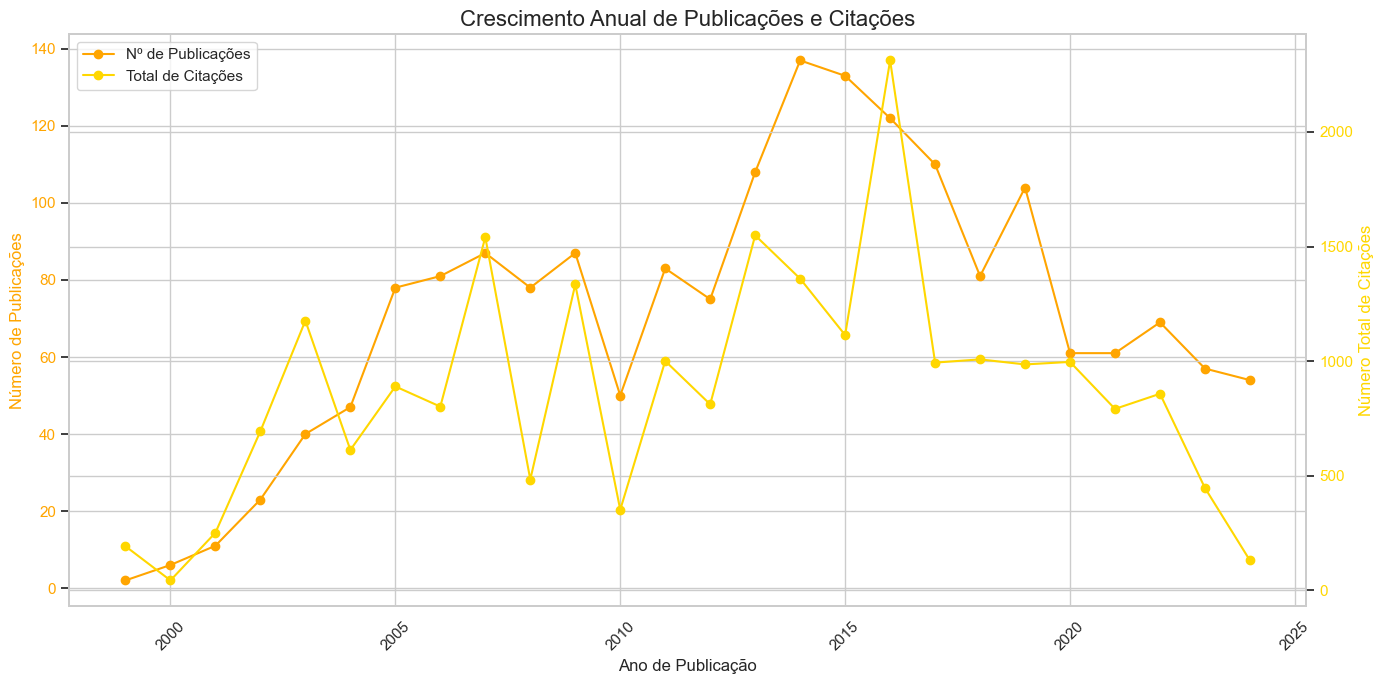

In [8]:
print("Iniciando a Análise 4: Tendência de Crescimento (Gráficos de Linha Dupla)...")

# Passo 1: Agrupar os dados por ano e calcular as métricas.
yearly_stats = df.groupby('Publication Year').agg(
    number_of_publications=('Article Title', 'count'),
    total_citations=('Times Cited, All Databases', 'sum')
).reset_index()

yearly_stats = yearly_stats[yearly_stats['Publication Year'] < 2025]
yearly_stats = yearly_stats.sort_values('Publication Year')

print("\nDados agregados dos últimos 5 anos para verificação:")
print(yearly_stats.tail())

# Passo 2: Criar o gráfico de eixo duplo com duas linhas.
fig, ax1 = plt.subplots(figsize=(14, 7))

# Cores para cada linha, conforme solicitado
color_publications = 'orange'
color_citations = 'gold'

# Eixo 1 (Esquerda): Linha para o Número de Publicações
ax1.set_xlabel('Ano de Publicação', fontsize=12)
ax1.set_ylabel('Número de Publicações', color=color_publications, fontsize=12)
ax1.plot(yearly_stats['Publication Year'], yearly_stats['number_of_publications'], 
         color=color_publications, marker='o', linestyle='-', label='Nº de Publicações')
ax1.tick_params(axis='y', labelcolor=color_publications)
#ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45)

# Eixo 2 (Direita): Linha para o Total de Citações
ax2 = ax1.twinx()
ax2.set_ylabel('Número Total de Citações', color=color_citations, fontsize=12)
ax2.plot(yearly_stats['Publication Year'], yearly_stats['total_citations'], 
         color=color_citations, marker='o', linestyle='-', label='Total de Citações')
ax2.tick_params(axis='y', labelcolor=color_citations)

# Passo 3: Finalizar e salvar o gráfico.
plt.title('Crescimento Anual de Publicações e Citações', fontsize=16)
fig.tight_layout()

# Adicionar uma legenda única para ambas as linhas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# Salvar a imagem do gráfico
output_filename = 'output_analise4.png'
plt.savefig(output_filename)

print(f"\nGráfico da Análise 4  gerado e salvo como '{output_filename}'")
# 2. Ordenar o DataFrame pelo número de citações
df_sorted = df.sort_values(by="Times Cited, All Databases", ascending=False)

# 3. Selecionar os 10 artigos mais citados
top_10_cited = df_sorted.head(10).copy() # Usar .copy() para evitar SettingWithCopyWarning

# 4. Calcular a média de citações por ano
CURRENT_YEAR = 2025
# Adiciona 1 para incluir o ano atual no cálculo da média
top_10_cited["Years since Publication"] = CURRENT_YEAR - top_10_cited["Publication Year"] + 1
top_10_cited["Average citations per year"] = top_10_cited["Times Cited, All Databases"] / top_10_cited["Years since Publication"]

# 5. Formatar e salvar o resultado
output_df = top_10_cited[["Article Title", "Times Cited, All Databases", "Average citations per year"]]

output_filename = 'artigos_mais_citados.csv'
output_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"SUCESSO! ✨ O arquivo '{output_filename}' com os 10 artigos mais citados foi criado.")
print("\\nAqui está uma prévia dos resultados:")
print(output_df.to_string(index=False))

***

#### 5: Analysis of Main Research Institutions

> *3.5. Analysis of Main Research Institutions.* From 2005 to 2020, Beijing University of Posts Telecommunications has published 115 literature studies, accounting for 4.21% of all literature studies in this field.
> ...
> The top 10 research institutions with the most published literature studies are shown in Figure 4.
> As can be seen from Figure 4, the top 10 research institutions are dominated by universities, and Chinese research institutions are the majority.

- Objetivo aqui é replicar o gráfico da figura 4. Os nomes das instituições já devem estar padronizados na base de dados, só puxar tudo da mesma coluna

**Figura 4:**

<img src="Images/Pasted image 20250816191951.png">

Iniciando a Análise 5: Principais Instituições de Pesquisa...

As 10 instituições com mais publicações são:
Affiliations
Anna University                                       54
Anna University Chennai                               37
Indian Institute of Technology System (IIT System)    37
Vellore Institute of Technology (VIT)                 34
University of California System                       30
National Institute of Technology (NIT System)         30
Egyptian Knowledge Bank (EKB)                         23
Islamic Azad University                               20
State University System of Florida                    19
SRM Institute of Science & Technology Chennai         19
Name: count, dtype: int64

Gráfico da Análise 5 (ordem invertida) gerado e salvo como 'output_analise5_top_institutions.png'
SUCESSO! ✨ O arquivo 'autores_mais_citados_total.csv' foi criado.

Os 10 autores mais citados no total são:
          Autor  Total de Citações
      Jain, Raj               1580
 Vaszk

C:\Users\macap\AppData\Local\Temp\ipykernel_20428\245168597.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_authors.rename(columns={'Authors_split': 'Autor', 'Times Cited, All Databases': 'Total de Citações'}, inplace=True)
C:\Users\macap\AppData\Local\Temp\ipykernel_20428\245168597.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


SUCESSO! ✨ Gráfico salvo como 'top_10_artigos_citados.png'


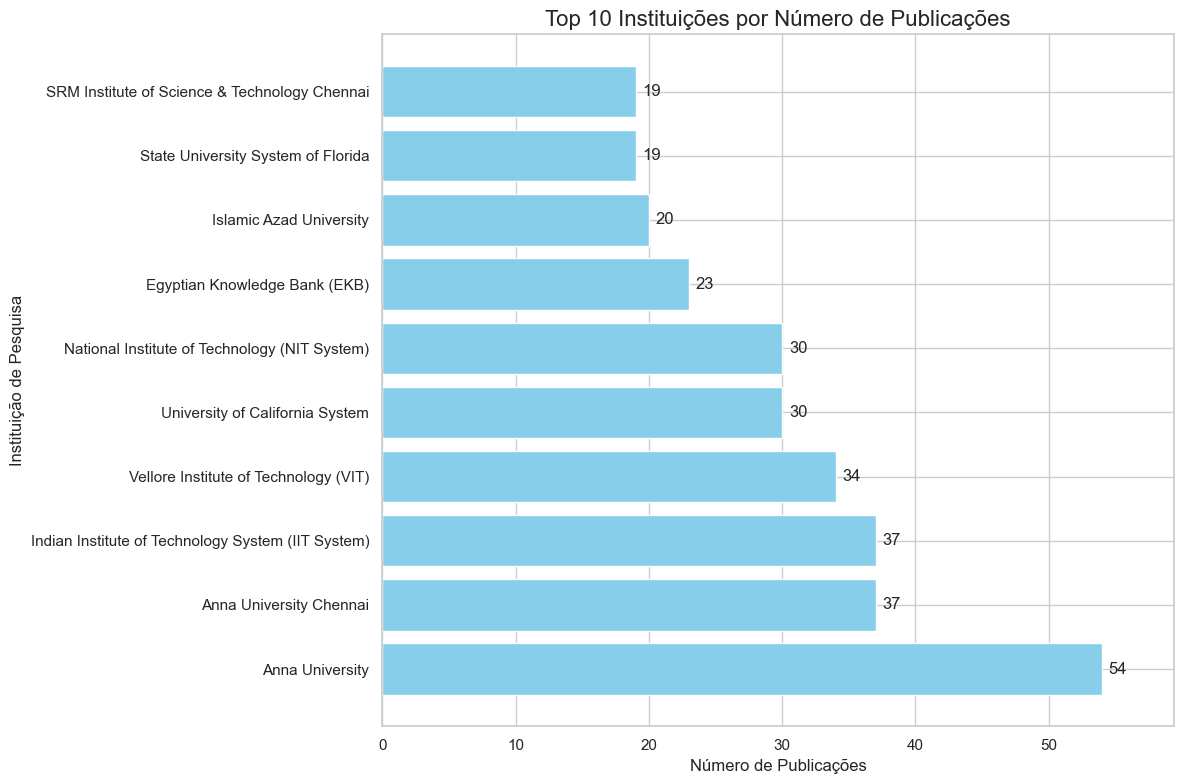

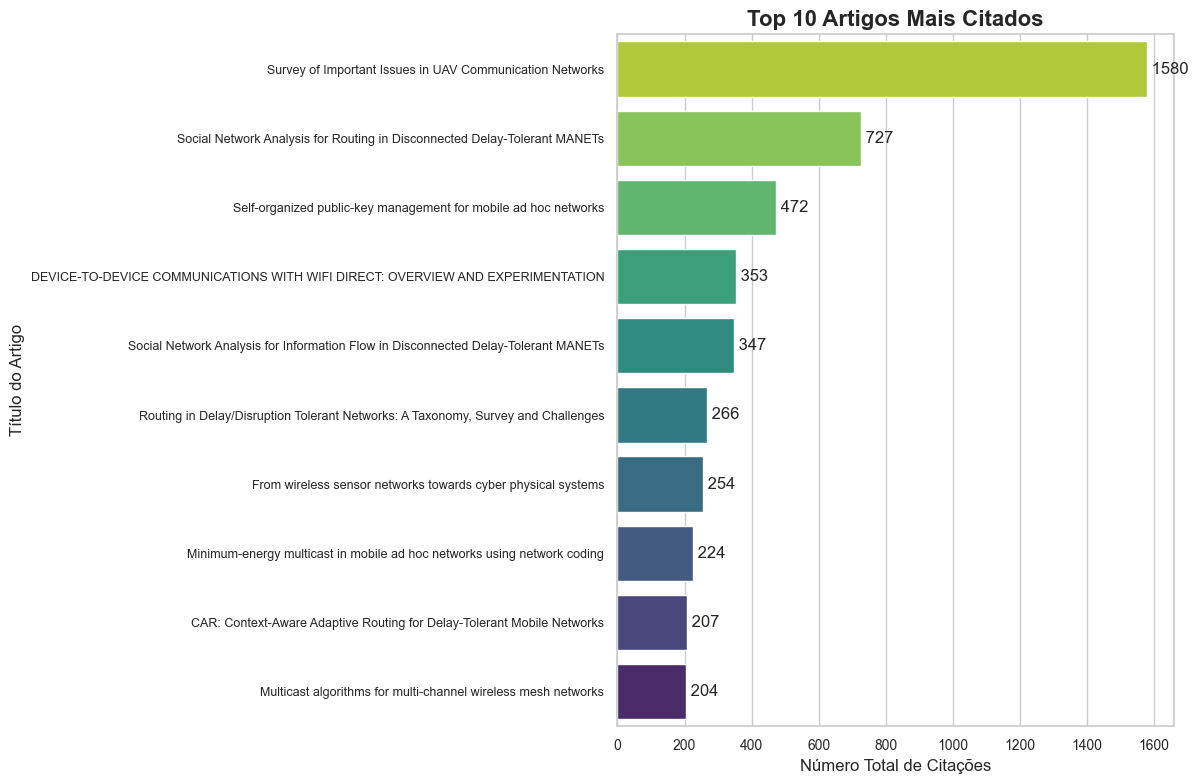

In [9]:
print("Iniciando a Análise 5: Principais Instituições de Pesquisa...")

# Passo 1: Identificar e processar a coluna de afiliações.
affiliation_column = 'Affiliations'

if affiliation_column not in df.columns:
    print(f"ERRO: A coluna '{affiliation_column}' não foi encontrada no DataFrame.")
    print(f"Por favor, verifique o nome da coluna de afiliações e atualize a variável 'affiliation_column'.")
    print(f"Colunas disponíveis: {df.columns.tolist()}")
else:
    # Remove linhas que não têm dados de afiliação
    df_cleaned = df.dropna(subset=[affiliation_column])
    
    # Separa as afiliações que estão juntas na mesma linha (delimitador ';')
    all_institutions = df_cleaned[affiliation_column].str.split(';').explode()
    
    # Limpa espaços em branco extras de cada nome
    all_institutions = all_institutions.str.strip()

    # Passo 2: Contar as publicações por instituição e pegar o top 10.
    top_10_institutions = all_institutions.value_counts().head(10)

    print("\nAs 10 instituições com mais publicações são:")
    print(top_10_institutions)

    # Passo 3: Criar o gráfico de barras horizontais.
    # A LINHA ABAIXO FOI ALTERADA PARA INVERTER A ORDEM DO GRÁFICO
    top_10_institutions = top_10_institutions.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 8))

    bars = ax.barh(top_10_institutions.index, top_10_institutions.values, color='skyblue')
    ax.set_xlabel('Número de Publicações', fontsize=12)
    ax.set_ylabel('Instituição de Pesquisa', fontsize=12)
    ax.set_title('Top 10 Instituições por Número de Publicações', fontsize=16)

    # Adicionar o número de publicações no final de cada barra
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                f'{int(width)}',
                ha='left', va='center')

    # Ajustar a margem para os números não serem cortados
    ax.margins(x=0.1)
    plt.tight_layout()

    # Salvar a imagem do gráfico
    output_filename = 'output_analise5_top_institutions.png'
    plt.savefig(output_filename)

    print(f"\nGráfico da Análise 5 (ordem invertida) gerado e salvo como '{output_filename}'")

        # Remover linhas onde as informações essenciais estão faltando
    df_autores = df.dropna(subset=['Author Full Names', 'Times Cited, All Databases']).copy()
    
    # Garantir que a coluna de citações seja numérica
    df_autores['Times Cited, All Databases'] = pd.to_numeric(df_autores['Times Cited, All Databases'])

    # Separar os autores em linhas individuais
    df_autores['Authors_split'] = df_autores['Author Full Names'].str.split(';')
    df_autores_exploded = df_autores.explode('Authors_split')
    df_autores_exploded['Authors_split'] = df_autores_exploded['Authors_split'].str.strip()

    # Agrupar por autor e somar as citações
    author_citations = df_autores_exploded.groupby('Authors_split')['Times Cited, All Databases'].sum().reset_index()
    
    # Ordenar para encontrar os mais citados
    author_citations_sorted = author_citations.sort_values(by='Times Cited, All Databases', ascending=False)
    
    # Selecionar o top 10 e formatar
    top_10_authors = author_citations_sorted.head(10)
    top_10_authors.rename(columns={'Authors_split': 'Autor', 'Times Cited, All Databases': 'Total de Citações'}, inplace=True)

    # Salvar o resultado em um novo arquivo CSV
    output_filename_authors = 'autores_mais_citados_total.csv'
    top_10_authors.to_csv(output_filename_authors, index=False, encoding='utf-8-sig')

    print(f"SUCESSO! ✨ O arquivo '{output_filename_authors}' foi criado.")
    print("\nOs 10 autores mais citados no total são:")
    print(top_10_authors.to_string(index=False))
    df['Times Cited, All Databases'] = pd.to_numeric(df['Times Cited, All Databases'], errors='coerce')
    df.dropna(subset=['Times Cited, All Databases', 'Article Title'], inplace=True)
    
    # Ordenar pelos mais citados e selecionar o top 10
    top_10_articles = df.sort_values(by='Times Cited, All Databases', ascending=False).head(10)
    
    # --- Criação do Gráfico ---
    
    # Configurar o estilo e o tamanho do gráfico
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 8))
    
    # Criar o gráfico de barras horizontais
    # Usamos 'y' para os títulos para que o mais citado apareça no topo
    barplot = sns.barplot(
        x='Times Cited, All Databases',
        y='Article Title',
        data=top_10_articles,
        palette='viridis_r', # Paleta de cores (r = reversed)
        orient='h'
    )
    
    # Adicionar títulos e rótulos para clareza
    plt.xlabel("Número Total de Citações", fontsize=12)
    plt.ylabel("Título do Artigo", fontsize=12)
    plt.title("Top 10 Artigos Mais Citados", fontsize=16, weight='bold')
    
    # Ajustar a legibilidade
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=9)
    plt.tight_layout() # Ajusta para evitar que os rótulos se sobreponham
    
    # Adicionar os valores no final de cada barra
    for index, value in enumerate(top_10_articles['Times Cited, All Databases']):
        plt.text(value, index, f' {int(value)}', va='center')
        
    # Salvar o gráfico em um arquivo
    output_filename = 'top_10_artigos_citados.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')

    print(f"SUCESSO! ✨ Gráfico salvo como '{output_filename}'")
    
    # Exibir o gráfico no notebook
    plt.show()

***

#### 6: Analysis of Notable Countries/Regions

> *3.6. Analysis of Notable Countries/Regions*. Considerable efforts have been made to promote the development of  to generate knowledge that can be used to solve problems encountered in practical applications of IoT. The top 10 most published countries are shown in Figure 5.
> ...
> A geographic visualization of research co-occurrence network is shown in Figure 6. According to Figure 6, countries all over the world attach great importance to , and there are three research intensive regions in the world, namely, Europe, southeast North America, and Southeast Asia.

- A análise da figura 5 parece ser simples de replicar
- Para a figura 6, os autores não parecem ter uma metodologia muito bem definida para o que é "co-ocorrência de pesquisa". A impressão que tenho é que eles só plotaram no mapa as coordenadas de cada instituição mencionada na base de dados e circularam onde tem mais densidade de instituições
	- Acho interessante fazer uma análise mais detalhada aqui (se tivermos tempo): podemos acabar achando regiões ligeiramente diferentes com uma metodologia mais cuidadosa (por ex. podemos achar um quarto cluster de pesquisa no sudeste dos EUA, na região da Califórnia)

**Figura 5:**

<img src="Images/Pasted image 20250816192542.png">

**Figura 6:**

<img src="Images/Pasted image 20250816192413.png">

In [16]:
countries_df = df.dropna(subset=["Addresses"]).copy()
countries_df["Addresses_split"] = (
    countries_df["Addresses"]
    .str.split("; [", regex=False)
    .apply(lambda lst: [s if s.startswith("[") else "[" + s for s in lst])
)

affiliations = (
    countries_df["Addresses_split"]
    .explode()
    .str.strip()
)

affiliations = affiliations.str.replace(r"^\[.*?\]\s*", "", regex=True)

parts = affiliations.str.split(", ")
last_parts = parts.str[-1]
countries = last_parts.str.split().str[-1]

first_parts = parts.str[0]

universities_df = pd.DataFrame({
    "ArticleIndex": affiliations.index, # original row index
    "University": first_parts
})

universities_unique_df = universities_df.drop_duplicates()

university_counts = (
    universities_unique_df["University"]
    .value_counts()
    .reset_index()
)

# Fix edge cases
countries = countries.replace("Republic", "Czech Republic")
countries = countries.replace("Zealand", "New Zealand")
countries = countries.replace("Arabia", "Saudi Arabia")
countries = countries.replace("Korea", "South Korea")

article_country_df = pd.DataFrame({
    "ArticleIndex": affiliations.index,  # original row index
    "Country": countries
})

article_country_unique_df = article_country_df.drop_duplicates()

country_counts = (
    article_country_unique_df["Country"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["Country", "PaperCount"]
university_counts.columns = ["University", "PaperCount"]

university_counts["University"] = university_counts["University"].str.replace(r"\bUniv\b", "University", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bTelecommun\b", "Telecommunications", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bAcad\b", "Academy", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bSci\b", "Science", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bElect\b", "Electronic", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bTechnol\b", "Technology", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bInst\b", "Institute", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bNatl\b", "National", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bPolytech\b", "Polytechnic", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bDef\b", "Defense", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bInformat\b", "Information", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bAmer\b", "American", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bProfess\b", "Professional", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bEngn\b", "Engineering", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bPolitecn\b", "Politecnica", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bAerosp\b", "Aerospace", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bColl\b", "College", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bRes\b", "Research", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bCtr\b", "Center", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bTech\b", "Technology", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bEduc\b", "Education", regex=True)
university_counts["University"] = university_counts["University"].str.replace(r"\bFed\b", "Federal", regex=True)

university_counts = university_counts.head(500)
country_counts.to_csv("output_analise6.csv")

geolocator = Nominatim(user_agent="univ_locator")

# Create new columns
university_counts["latitude"] = None
university_counts["longitude"] = None

for i, name in tqdm(enumerate(university_counts["University"]), total=len(university_counts)):
    try:
        location = geolocator.geocode(name, timeout=10)
        if location:
            university_counts.at[i, "latitude"] = location.latitude
            university_counts.at[i, "longitude"] = location.longitude
    except Exception as e:
        print(f"Error on {name}: {e}")
    time.sleep(1)  # avoid rate limiting

university_counts.to_csv("coordinates.csv")


100%|██████████| 500/500 [15:27<00:00,  1.86s/it]


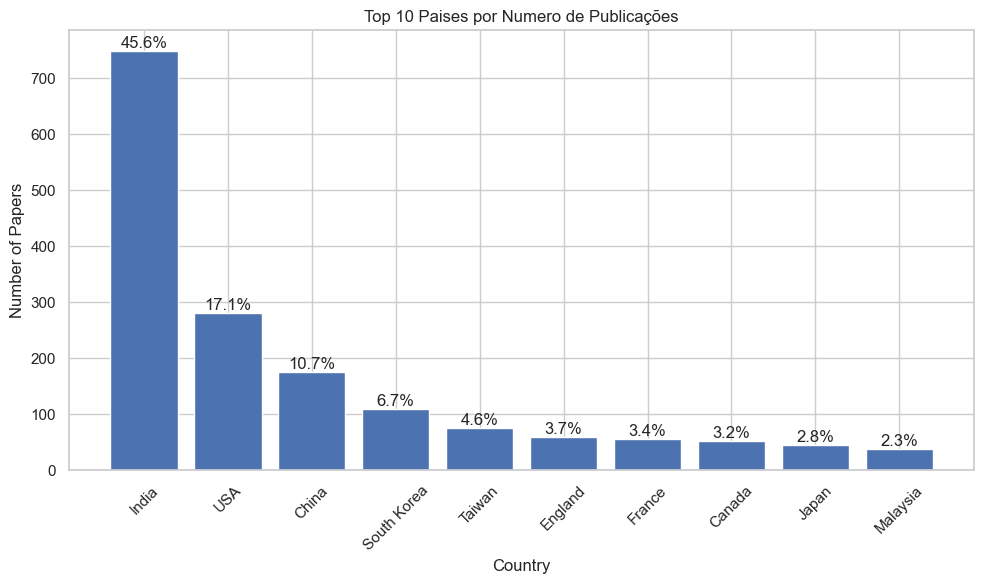

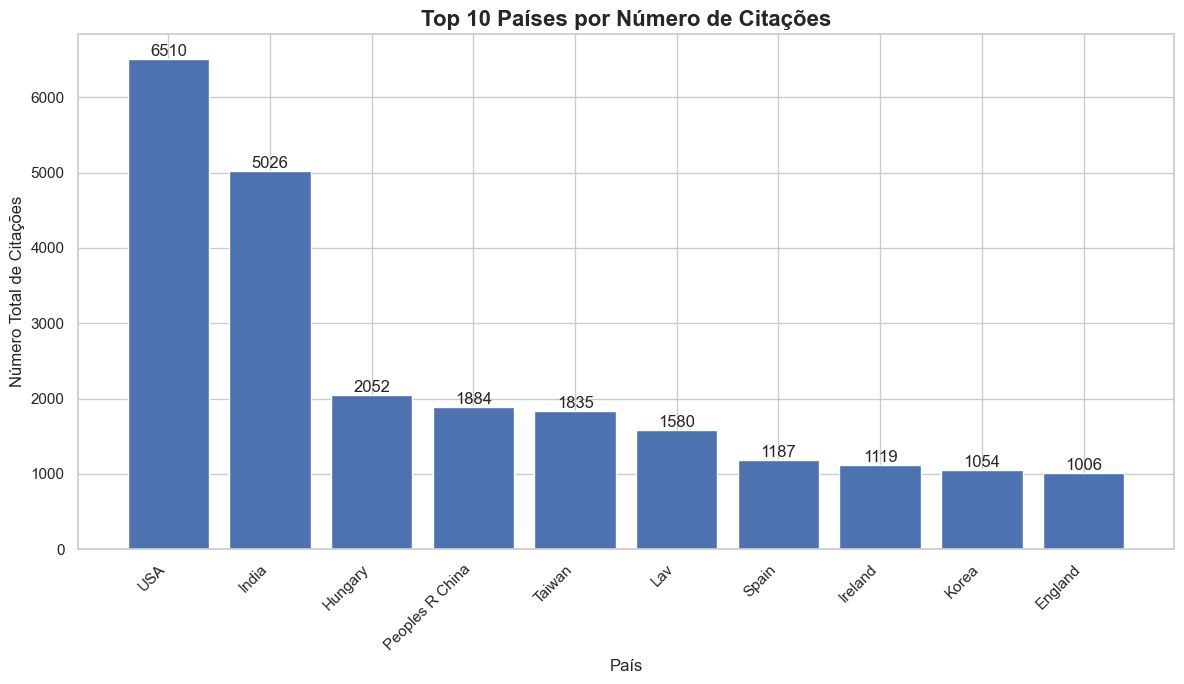


--- Top 10 Países por Citação ---

           País  Total de Citações
            USA               6510
          India               5026
        Hungary               2052
Peoples R China               1884
         Taiwan               1835
            Lav               1580
          Spain               1187
        Ireland               1119
          Korea               1054
        England               1006

Resultados salvos em 'output_paises_por_citacao.csv'


In [12]:
countries_for_plot = pd.read_csv("output_analise6.csv")

top10 = countries_for_plot.head(10)

# Compute total for percentage
total = top10["PaperCount"].sum()

# Plot
plt.figure(figsize=(10,6))
bars = plt.bar(top10["Country"], top10["PaperCount"])
plt.title("Top 10 Paises por Numero de Publicações")
plt.xlabel("Country")
plt.ylabel("Number of Papers")
plt.xticks(rotation=45)

# Add percentage labels above bars
for bar, value in zip(bars, top10["PaperCount"]):
    percentage = (value / total) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
        bar.get_height(),                   # y position (top of bar)
        f"{percentage:.1f}%",               # label text
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

# ##############################################################################
# ## ANÁLISE: TOP PAÍSES POR NÚMERO DE CITAÇÕES (CÓDIGO CORRIGIDO)
# ##############################################################################

# Passo 1: DEFINIR A FUNÇÃO PRIMEIRO
def get_countries_from_address(address_str):
    """Extrai uma lista de países únicos de uma string de endereço da WoS."""
    if not isinstance(address_str, str):
        return []
    countries = set()
    affiliations = address_str.split(';')
    for aff in affiliations:
        # Pega a última palavra do endereço, que geralmente é o país
        country = aff.strip().split()[-1]
        # Remove caracteres indesejados como '.'
        country = country.replace('.', '')
        # Correções comuns para padronizar nomes
        if country.lower() == 'china':
            country = 'Peoples R China'
        countries.add(country)
    return list(countries)

# Passo 2: Preparar os dados, explodir afiliações e extrair países
citation_col = 'Times Cited, All Databases'
country_citations_df = df[['Addresses', citation_col]].dropna().copy()

# Agora podemos chamar a função, pois ela já foi definida
country_citations_df['CountryList'] = country_citations_df['Addresses'].apply(get_countries_from_address)
exploded_citations_df = country_citations_df.explode('CountryList')

# Passo 3: Agrupar por país e somar as citações
country_total_citations = (
    exploded_citations_df.groupby('CountryList')[citation_col]
    .sum()
    .reset_index()
)

# Passo 4: Renomear colunas e ordenar para pegar os top 10
country_total_citations.columns = ['País', 'Total de Citações']
country_total_citations = country_total_citations.sort_values(by='Total de Citações', ascending=False)
top_10_cited_countries = country_total_citations.head(10)

# Passo 5: Gerar o gráfico de barras
plt.figure(figsize=(12, 7))
bars_citations = plt.bar(
    top_10_cited_countries['País'],
    top_10_cited_countries['Total de Citações'],
)
plt.title("Top 10 Países por Número de Citações", fontsize=16, weight='bold')
plt.xlabel("País", fontsize=12)
plt.ylabel("Número Total de Citações", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Adicionar os valores totais (números absolutos) acima das barras
for bar in bars_citations:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{int(yval)}', va='bottom', ha='center')

plt.tight_layout()
plt.savefig("top_10_paises_citacoes.png", dpi=300)
plt.show()

# Passo 6: Exibir os resultados e salvar em CSV
print("\n--- Top 10 Países por Citação ---\n")
print(top_10_cited_countries.to_string(index=False))
top_10_cited_countries.to_csv("output_paises_por_citacao.csv", index=False)
print("\nResultados salvos em 'output_paises_por_citacao.csv'")

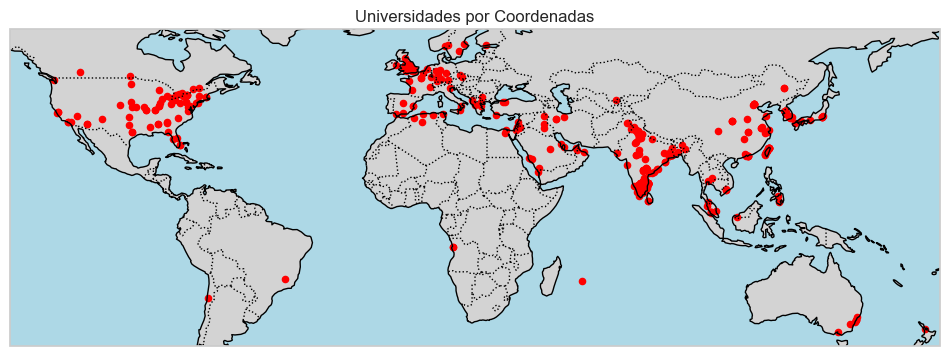

In [20]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df = pd.read_csv("coordinates.csv")

# Create a figure with a world map projection
plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="black")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")

# Scatter plot universities
ax.scatter(df["longitude"], df["latitude"],
           color="red", s=20, transform=ccrs.PlateCarree())

plt.title("Universidades por Coordenadas")
plt.show()

***

#### 7: Analysis of Hotspots

> *3.7. Analysis of Hotspots.* Keywords are an important part of the literature, which highly condense the content of the literature.
> ...
> The minimum number of occurrences of a keyword was set 40 in VOSviewer. After merging  and its synonyms, four clusters of high-frequency keywords were obtained, whose nodes of the same color belong to the same cluster.
> ...
> Keywords of “edge computing,” “Internet of Things,” “Internet,” and “IoT” are not shown because literature studies retrieved all related to “edge computing” and “Internet of Things.”
> 
> 1. **Cluster 1** is the study of specific difficult problems of , as shown in the **red** node region. The specific problems of  include resource management, resource allocation, computation offloading, energy consumption, and delay.
> 2. **Cluster 2** is the study of the overall architecture of , as shown in the **green** node region. Through the optimization and innovation of the overallarchitecture, the protection of privacy and security will be further increased.
> 3. **Cluster 3** is the study of  applications, as shown in the **blue** node region. Mobile computing is combined with big data technology and artificial intelligence algorithms to make  better applied in smart homes, smart city, and some other fields. 
> 4. **Cluster 4** is the study of mobile edge computing (MEC) with 5G, as shown in **yellow** node area. The development of 5G ensures high bandwidth and low latency in the transmission process, which provides the network security for . With the continuous maturity of 5G technology, the study of MEC will also usher in rapid development.
> 
> ...
> The literature keyword analysis not only provides an effective way for the knowledge structure of the research field but also provides an effective way for the exploration of the development trend in the field. Therefore, it can be speculated that problems of  related to resource management, resource allocation, computation offloading, energy consumption, and delay will be further studied in the future.

- Aqui a análise é feita inteiramente no VOSViewer, então não precisamos de nenhum tratamento adicional de dados em Python.
- Única configuração necessária é `Minimum number of keyword ocurrences = 40`